# Sound Realty Prediction Model Evaluation

Evaluate the performance of the model. Start with the code in `create_model.py`.  
* Try to figure out how well the model will generalize to new data.
* Has the model appropriately fit the dataset?

In [1]:
# from the original script
import json
import pathlib
import pickle
from typing import List
from typing import Tuple

import pandas as pd
from sklearn import model_selection
from sklearn import neighbors
from sklearn import pipeline
from sklearn import preprocessing

In [24]:
# more that we need
#import mlflow
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
SALES_PATH = "data/kc_house_data.csv"  # path to CSV with home sale data
DEMOGRAPHICS_PATH = "data/zipcode_demographics.csv"  # path to CSV with demographics
# List of columns (subset) that will be taken from home sale data
SALES_COLUMN_SELECTION = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'sqft_above', 'sqft_basement', 'zipcode'
]
OUTPUT_DIR = "model"  # Directory where output artifacts will be saved

In [3]:
def load_data(
    sales_path: str, demographics_path: str, sales_column_selection: List[str]
) -> Tuple[pd.DataFrame, pd.Series]:
    """Load the target and feature data by merging sales and demographics.

    Args:
        sales_path: path to CSV file with home sale data
        demographics_path: path to CSV file with home sale data
        sales_column_selection: list of columns from sales data to be used as
            features
            If set to None, then all columns will be used

    Returns:
        Tuple containg with two elements: a DataFrame and a Series of the same
        length.  The DataFrame contains features for machine learning, the
        series contains the target variable (home sale price).

    """
    data = pd.read_csv(sales_path,
                           usecols=sales_column_selection,
                           dtype={'zipcode': str})
    demographics = pd.read_csv(demographics_path,
                                   dtype={'zipcode': str})

    merged_data = data.merge(demographics, how="left",
                             on="zipcode").drop(columns="zipcode")
    # Remove the target variable from the dataframe, features will remain
    y = merged_data.pop('price')
    x = merged_data

    return x, y

In [17]:
# the load command from the original script
#x, y = load_data(SALES_PATH, DEMOGRAPHICS_PATH, SALES_COLUMN_SELECTION)

# modified
x, y = load_data(SALES_PATH, DEMOGRAPHICS_PATH, None)

In [18]:
x.columns

Index(['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'ppltn_qty', 'urbn_ppltn_qty',
       'sbrbn_ppltn_qty', 'farm_ppltn_qty', 'non_farm_qty',
       'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt', 'hous_val_amt',
       'edctn_less_than_9_qty', 'edctn_9_12_qty', 'edctn_high_schl_qty',
       'edctn_some_clg_qty', 'edctn_assoc_dgre_qty', 'edctn_bchlr_dgre_qty',
       'edctn_prfsnl_qty', 'per_urbn', 'per_sbrbn', 'per_farm', 'per_non_farm',
       'per_less_than_9', 'per_9_to_12', 'per_hsd', 'per_some_clg',
       'per_assoc', 'per_bchlr', 'per_prfsnl'],
      dtype='object')

In [19]:
# drop 'id' and 'date', since like 'price', they will not be available in new data.
x.pop('id')
x.pop('date')
x.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'ppltn_qty', 'urbn_ppltn_qty',
       'sbrbn_ppltn_qty', 'farm_ppltn_qty', 'non_farm_qty',
       'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt', 'hous_val_amt',
       'edctn_less_than_9_qty', 'edctn_9_12_qty', 'edctn_high_schl_qty',
       'edctn_some_clg_qty', 'edctn_assoc_dgre_qty', 'edctn_bchlr_dgre_qty',
       'edctn_prfsnl_qty', 'per_urbn', 'per_sbrbn', 'per_farm', 'per_non_farm',
       'per_less_than_9', 'per_9_to_12', 'per_hsd', 'per_some_clg',
       'per_assoc', 'per_bchlr', 'per_prfsnl'],
      dtype='object')

In [20]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 43 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   bedrooms                21613 non-null  int64  
 1   bathrooms               21613 non-null  float64
 2   sqft_living             21613 non-null  int64  
 3   sqft_lot                21613 non-null  int64  
 4   floors                  21613 non-null  float64
 5   waterfront              21613 non-null  int64  
 6   view                    21613 non-null  int64  
 7   condition               21613 non-null  int64  
 8   grade                   21613 non-null  int64  
 9   sqft_above              21613 non-null  int64  
 10  sqft_basement           21613 non-null  int64  
 11  yr_built                21613 non-null  int64  
 12  yr_renovated            21613 non-null  int64  
 13  lat                     21613 non-null  float64
 14  long                    21613 non-null

## Start exploring the data set

In [21]:
# count NULL values
x.isnull().sum()

bedrooms                  0
bathrooms                 0
sqft_living               0
sqft_lot                  0
floors                    0
waterfront                0
view                      0
condition                 0
grade                     0
sqft_above                0
sqft_basement             0
yr_built                  0
yr_renovated              0
lat                       0
long                      0
sqft_living15             0
sqft_lot15                0
ppltn_qty                 0
urbn_ppltn_qty            0
sbrbn_ppltn_qty           0
farm_ppltn_qty            0
non_farm_qty              0
medn_hshld_incm_amt       0
medn_incm_per_prsn_amt    0
hous_val_amt              0
edctn_less_than_9_qty     0
edctn_9_12_qty            0
edctn_high_schl_qty       0
edctn_some_clg_qty        0
edctn_assoc_dgre_qty      0
edctn_bchlr_dgre_qty      0
edctn_prfsnl_qty          0
per_urbn                  0
per_sbrbn                 0
per_farm                  0
per_non_farm        

In [22]:
# check summary statistics
x.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
bedrooms,21613.0,3.370842,0.930062,0.0000,3.000,3.0000,4.000,3.300000e+01
bathrooms,21613.0,2.114757,0.770163,0.0000,1.750,2.2500,2.500,8.000000e+00
sqft_living,21613.0,2079.899736,918.440897,290.0000,1427.000,1910.0000,2550.000,1.354000e+04
sqft_lot,21613.0,15106.967566,41420.511515,520.0000,5040.000,7618.0000,10688.000,1.651359e+06
floors,21613.0,1.494309,0.539989,1.0000,1.000,1.5000,2.000,3.500000e+00
waterfront,21613.0,0.007542,0.086517,0.0000,0.000,0.0000,0.000,1.000000e+00
view,21613.0,0.234303,0.766318,0.0000,0.000,0.0000,0.000,4.000000e+00
condition,21613.0,3.409430,0.650743,1.0000,3.000,3.0000,4.000,5.000000e+00
grade,21613.0,7.656873,1.175459,1.0000,7.000,7.0000,8.000,1.300000e+01
sqft_above,21613.0,1788.390691,828.090978,290.0000,1190.000,1560.0000,2210.000,9.410000e+03


In [23]:
# check correlation between features
x.corr()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,per_sbrbn,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl
bedrooms,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,...,0.001661,-0.042594,-0.026351,-0.086792,-0.096682,-0.068864,-0.030933,-0.008414,0.037193,0.037306
bathrooms,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,...,0.044711,-0.019166,0.049680,-0.181868,-0.215639,-0.186568,-0.083487,-0.044129,0.139712,0.108809
sqft_living,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,...,0.041841,-0.013820,0.045768,-0.200182,-0.234820,-0.208608,-0.117960,-0.098720,0.151996,0.142384
sqft_lot,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,...,0.068312,0.268381,0.310589,-0.077651,-0.013027,0.040087,0.001913,-0.045225,-0.078171,-0.082581
floors,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,...,0.058619,-0.018184,0.060553,-0.125511,-0.146449,-0.159675,-0.043665,-0.004973,0.160609,0.115641
waterfront,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,...,-0.013694,0.031047,0.066097,0.002125,-0.005975,-0.006542,0.003151,-0.017437,-0.001246,0.022077
view,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,...,0.009155,0.052207,0.028679,-0.017205,-0.041473,-0.048329,-0.019586,-0.076917,0.062929,0.093457
condition,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,...,-0.075707,0.015278,-0.048166,-0.011459,-0.027204,-0.023600,-0.005919,-0.054353,0.048770,0.083790
grade,0.356967,0.664983,0.762704,0.113621,0.458183,0.082775,0.251321,-0.144674,1.000000,0.755923,...,0.011116,-0.051817,-0.012106,-0.257511,-0.315026,-0.307817,-0.125707,-0.100219,0.262328,0.238433
sqft_above,0.477600,0.685342,0.876597,0.183512,0.523885,0.072075,0.167649,-0.158214,0.755923,1.000000,...,0.078792,0.018394,0.107578,-0.224076,-0.211875,-0.157029,-0.098545,-0.061935,0.092396,0.058769


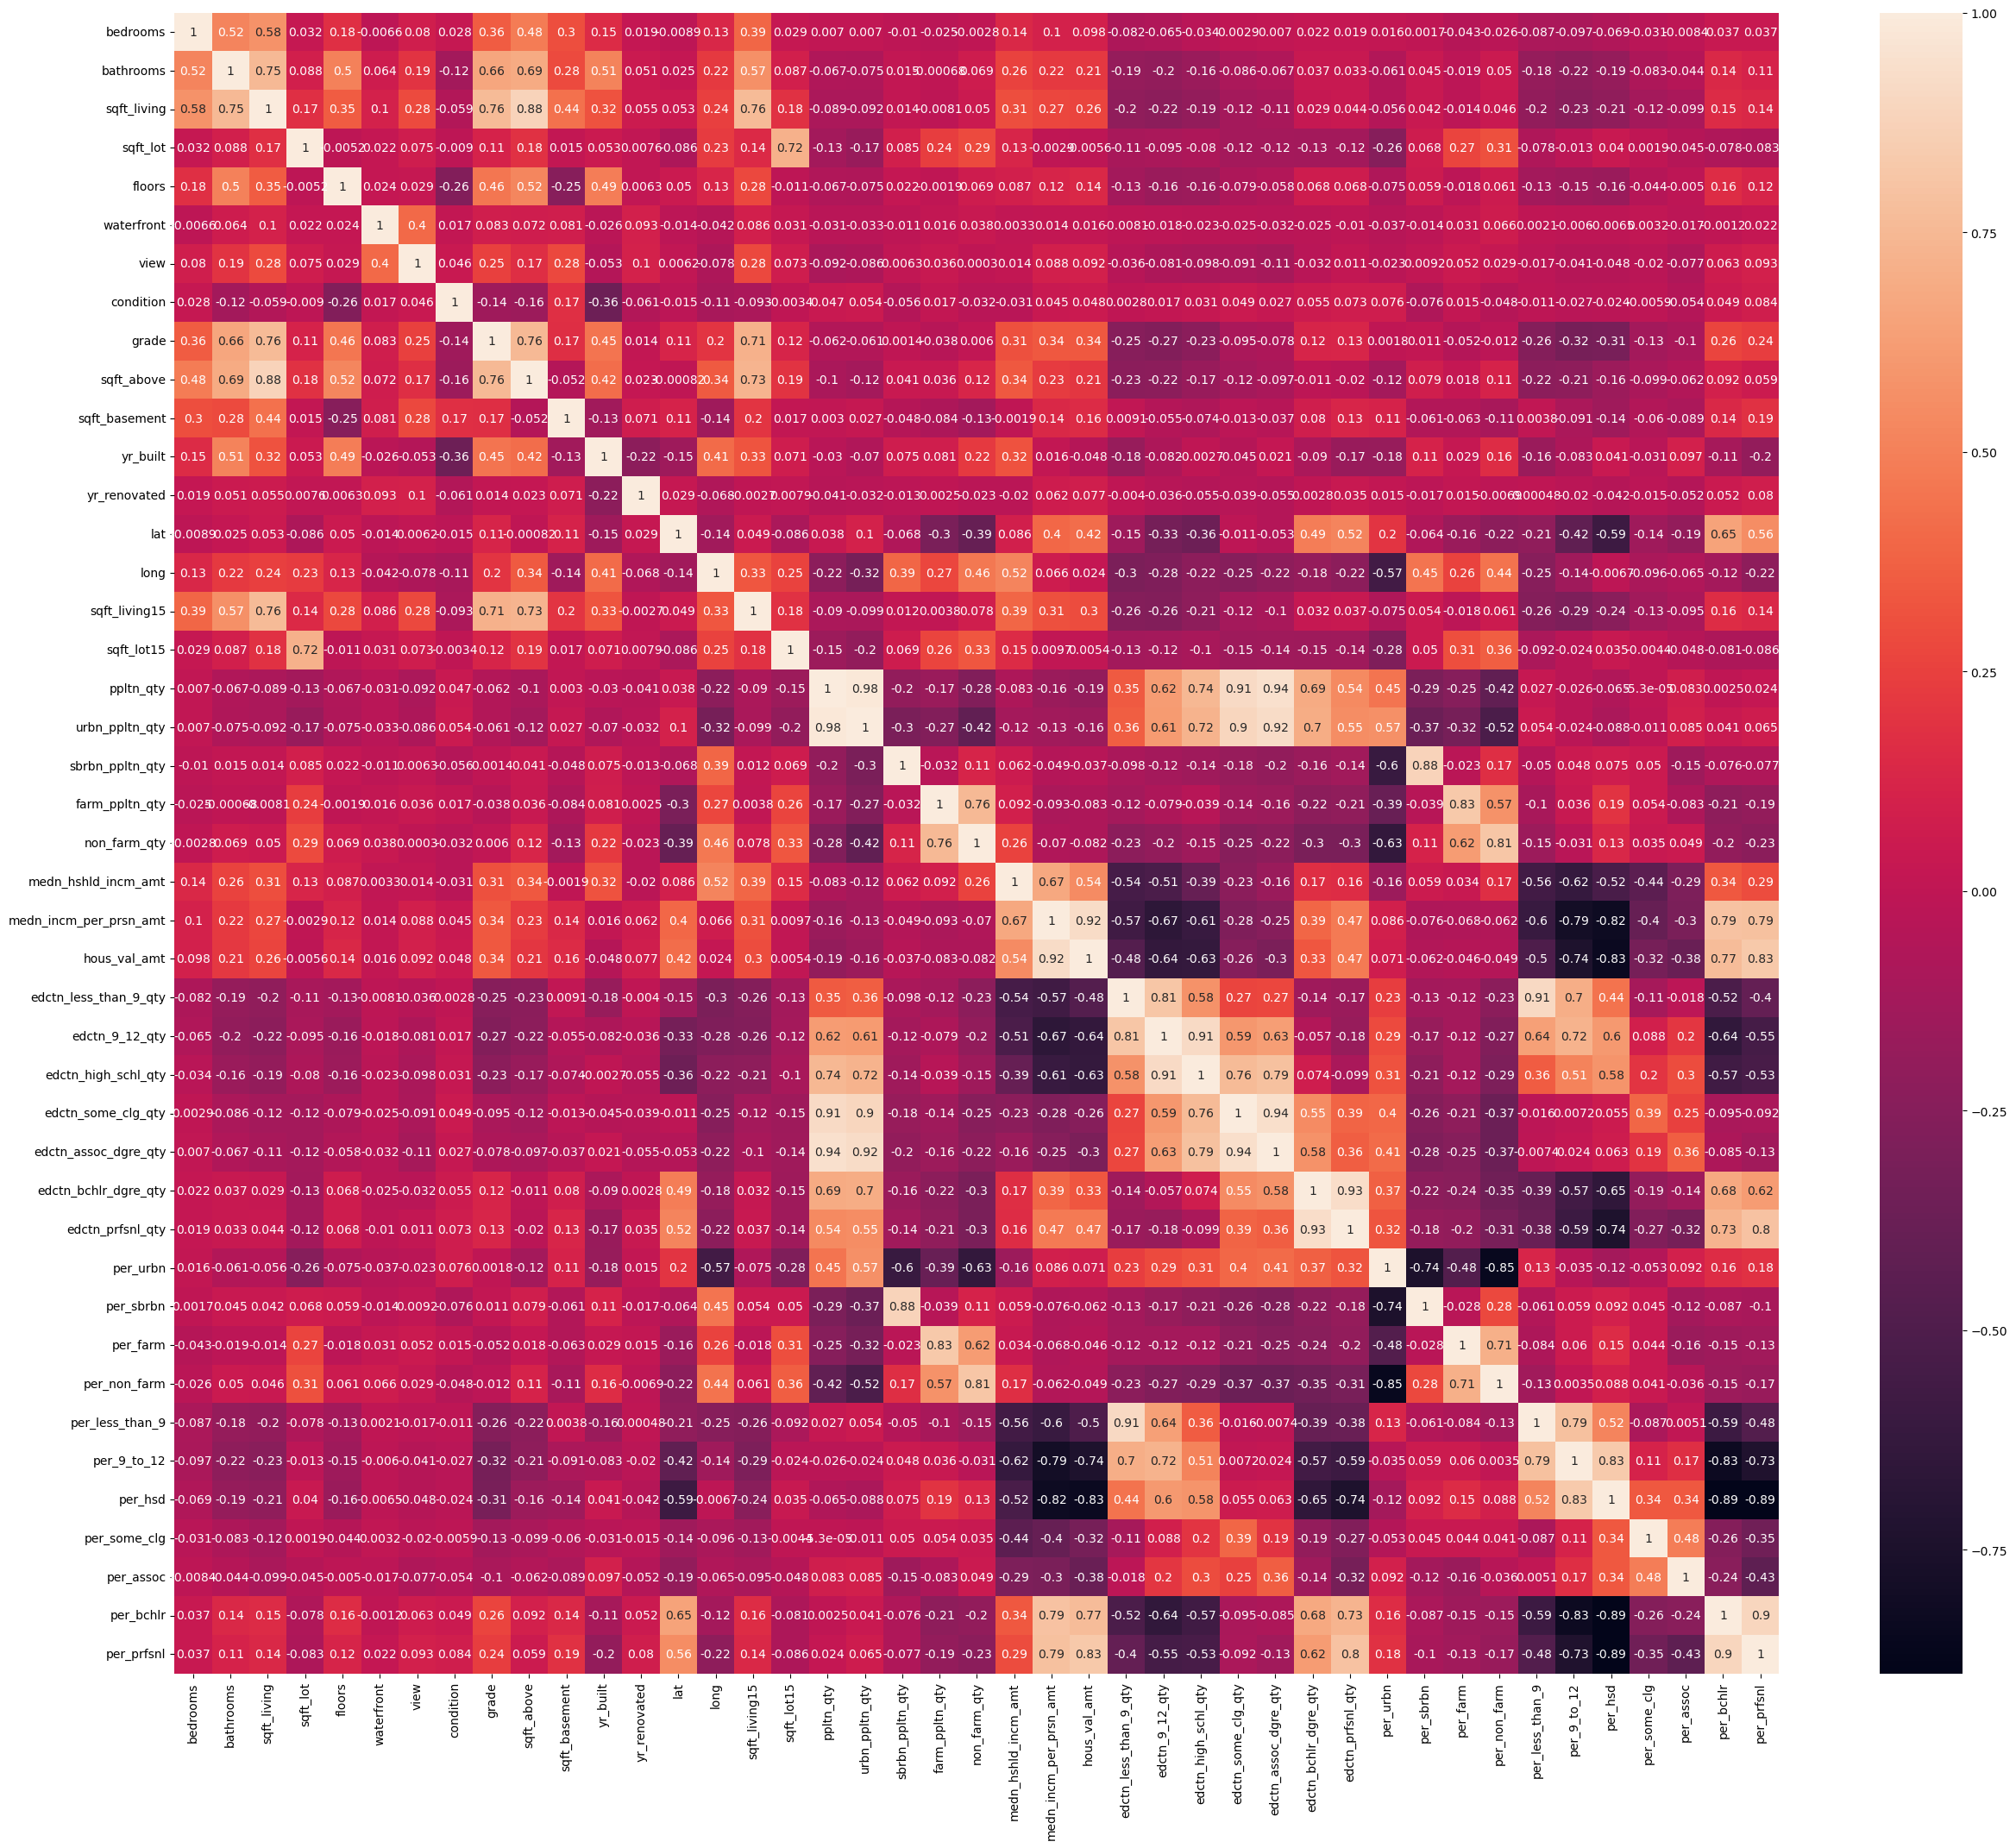

In [27]:
# that is hard to look at.  Try a heatmap.
fig1, ax = plt.subplots(figsize = (30, 25))
sns.heatmap(x.corr(), annot = True)
plt.show()

In [29]:
# check a heatmap for the columns that were used in the model
x1, y1 = load_data(SALES_PATH, DEMOGRAPHICS_PATH, SALES_COLUMN_SELECTION)
x1.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'sqft_above', 'sqft_basement', 'ppltn_qty', 'urbn_ppltn_qty',
       'sbrbn_ppltn_qty', 'farm_ppltn_qty', 'non_farm_qty',
       'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt', 'hous_val_amt',
       'edctn_less_than_9_qty', 'edctn_9_12_qty', 'edctn_high_schl_qty',
       'edctn_some_clg_qty', 'edctn_assoc_dgre_qty', 'edctn_bchlr_dgre_qty',
       'edctn_prfsnl_qty', 'per_urbn', 'per_sbrbn', 'per_farm', 'per_non_farm',
       'per_less_than_9', 'per_9_to_12', 'per_hsd', 'per_some_clg',
       'per_assoc', 'per_bchlr', 'per_prfsnl'],
      dtype='object')

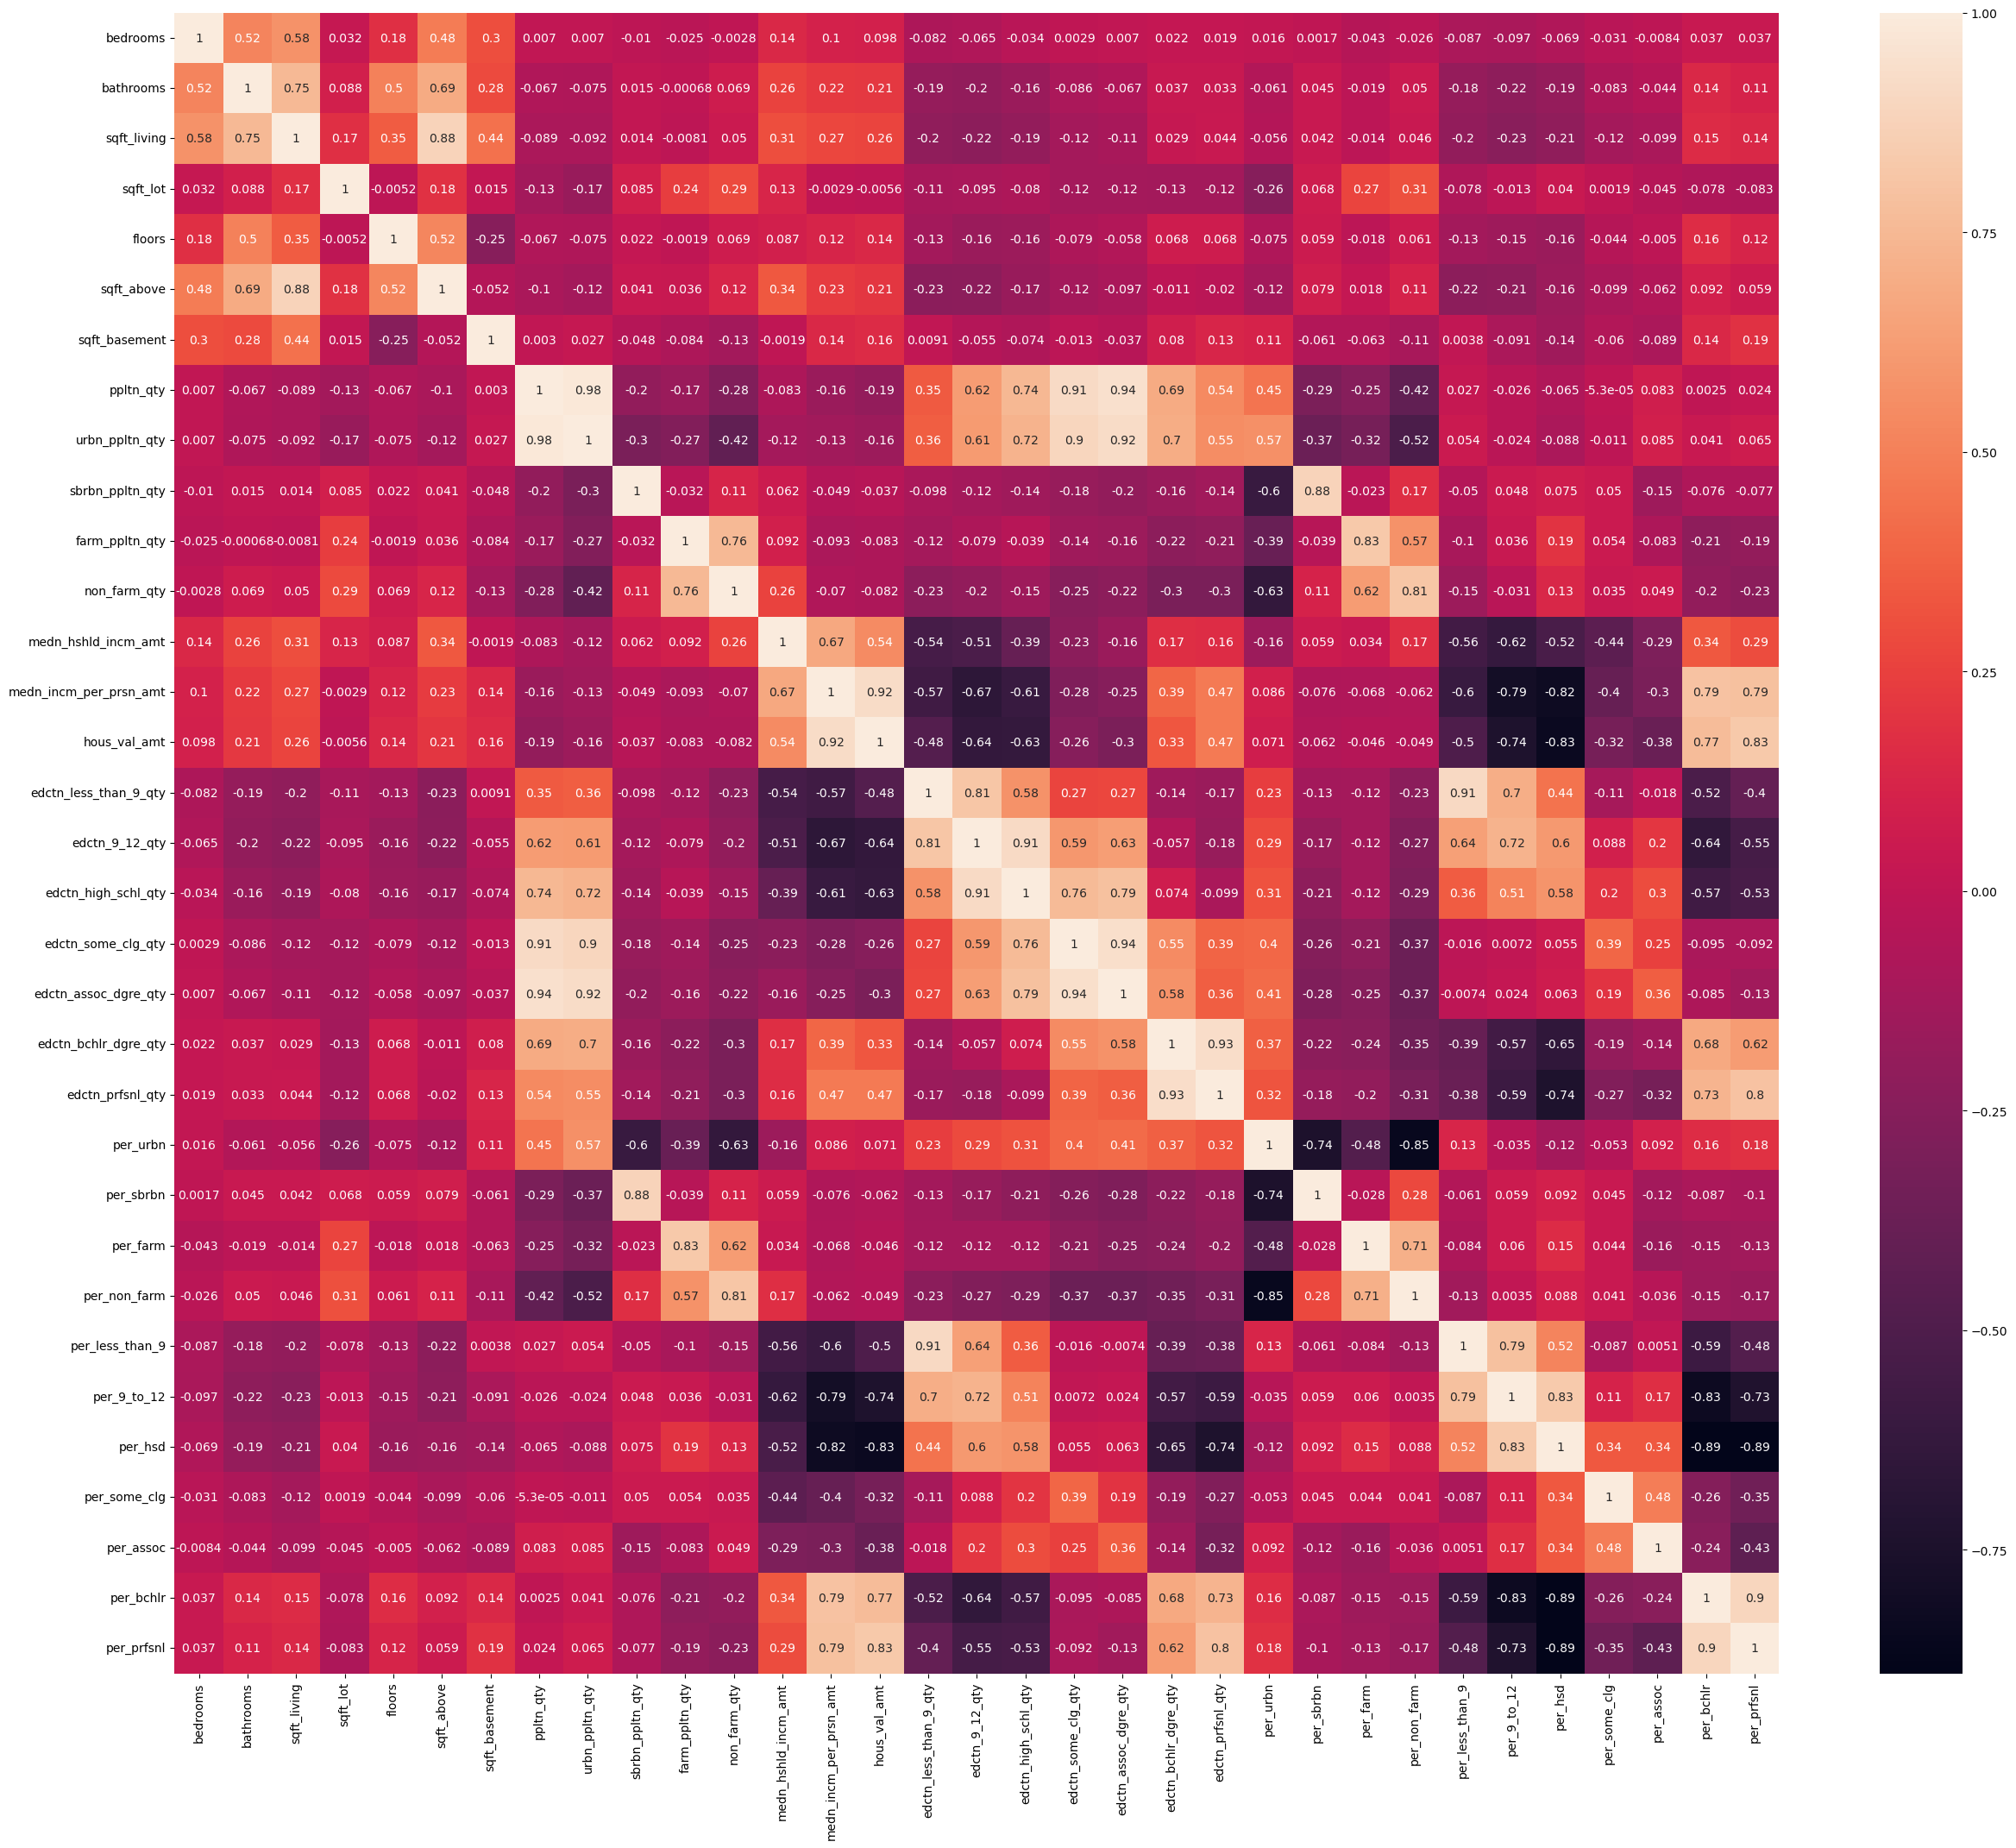

In [31]:
fig1, ax = plt.subplots(figsize = (30, 25))
sns.heatmap(x1.corr(), annot = True)
plt.show()

## Consider the scaling used in the model

The submitted model uses `RobustScaler` to scale every feature.  This differs from another common choice, `StandardScaler`, in that it uses medians and interquartile ranges for scaling, rather than means and standard deviations.

Note that in the full dataset, some features have `0.0` for their interquartile range (75% - 25%) values.  Were these the features that were left out of the model?

In [35]:
# features with 0 for interquartile (75% - 25%) values
# subtract quartiles to check
q_check = x.describe().transpose()[['25%','50%','75%']]
q_check['IQD']=q_check['75%']-q_check['25%']

display(q_check)

,25%,50%,75%,IQD
bedrooms,3.000,3.0000,4.000,1.000
bathrooms,1.750,2.2500,2.500,0.750
sqft_living,1427.000,1910.0000,2550.000,1123.000
sqft_lot,5040.000,7618.0000,10688.000,5648.000
floors,1.000,1.5000,2.000,1.000
waterfront,0.000,0.0000,0.000,0.000
view,0.000,0.0000,0.000,0.000
condition,3.000,3.0000,4.000,1.000
grade,7.000,7.0000,8.000,1.000
sqft_above,1190.000,1560.0000,2210.000,1020.000


In [37]:
# collect column names for columns not suitable for use with RobustScaler
bad_interquartile_columns = [
    'waterfront',
    'view',
    'yr_renovated',
    'sbrbn_ppltn_qty', 
    'farm_ppltn_qty', 
    'per_sbrbn',
    'per_farm',
    'per_non_farm'
]
# compare:
print(bad_interquartile_columns)
print(SALES_COLUMN_SELECTION)

['waterfront', 'view', 'yr_renovated', 'sbrbn_ppltn_qty', 'farm_ppltn_qty', 'per_sbrbn', 'per_farm', 'per_non_farm']
['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'sqft_above', 'sqft_basement', 'zipcode']


## Suggestion based on bad_interquartile_columns:

If the reason those columns were left out is because they are not able to be scaled using `RobustScaler` due to having `0 IQD`, then consider including them and scale these columns with `StandardScaler` instead.  (Unless there is another reason, such as high correlation, to leave them out.)

In [42]:
# what other columns are there?
x_columns = x.columns.to_list()
print(x_columns)
print("")
remaining_columns = [column for column in x_columns if column not in bad_interquartile_columns+SALES_COLUMN_SELECTION]
print(remaining_columns)

['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'ppltn_qty', 'urbn_ppltn_qty', 'sbrbn_ppltn_qty', 'farm_ppltn_qty', 'non_farm_qty', 'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt', 'hous_val_amt', 'edctn_less_than_9_qty', 'edctn_9_12_qty', 'edctn_high_schl_qty', 'edctn_some_clg_qty', 'edctn_assoc_dgre_qty', 'edctn_bchlr_dgre_qty', 'edctn_prfsnl_qty', 'per_urbn', 'per_sbrbn', 'per_farm', 'per_non_farm', 'per_less_than_9', 'per_9_to_12', 'per_hsd', 'per_some_clg', 'per_assoc', 'per_bchlr', 'per_prfsnl']

['condition', 'grade', 'yr_built', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'ppltn_qty', 'urbn_ppltn_qty', 'non_farm_qty', 'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt', 'hous_val_amt', 'edctn_less_than_9_qty', 'edctn_9_12_qty', 'edctn_high_schl_qty', 'edctn_some_clg_qty', 'edctn_assoc_dgre_qty', 'edctn_bchlr_dgre_qty',

## Examine the K-Nearest Neighbors regressor

In the provided model training code, the step after scaling the data is regression using scikit-learn's `KNeighorsRegressor`.  This regressor is put into the pipeline using default parameters.  It is useful to note that the use of parameters can improve the performance of this regressor.  

Some sample parameters worth trying non-default values for:
* `n_neighbors` (default 5): Number of neighbors to use
* `weights` (default 'uniform'): Weight function used in prediction.  Could be 'uniform', 'distance' (for inverse distance), or a different function of distance.

Alternatively, consider using an alternate regressor such as `RandomForestRegressor`.

## Consider generalization to new data

We want to ensure that this model will perform well on new, unseen data.  

One way to approach this is to check for overfitting.  That is, can the model make predicions, or has it just memorized the training data?

I'll try checking for overfitting using cross-validation.

In [51]:
from sklearn.model_selection import cross_val_score, KFold

# the data features x and target y were defined previously.

# model fit from the Sound Realty code:
#model = pipeline.make_pipeline(preprocessing.RobustScaler(),
#                               neighbors.KNeighborsRegressor()).fit(
#                                    x_train, y_train)
# modified to use with cross_val_score:
sound_pipeline = pipeline.Pipeline([
    ('scaler', preprocessing.RobustScaler()),
    ('knn', neighbors.KNeighborsRegressor())
])

# Define the cross-validation strategy
# Here, we use KFold with 5 splits, shuffling the data
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation on the pipeline
# The cross_val_score function will fit and evaluate the entire pipeline
# for each fold of the cross-validation
scores = cross_val_score(sound_pipeline, x, y, cv=cv, scoring='r2')

# Print the cross-validation scores and their mean
print(f"Cross-validation scores: {scores}")
print(f"Mean r^2 score: {scores.mean():.4f}")
print(f"Standard Deviation of r^2 score: {scores.std():.4f}")



Cross-validation scores: [0.77514368 0.77252219 0.78322851 0.81362643 0.80378863]
Mean r^2 score: 0.7897
Standard Deviation of r^2 score: 0.0162


In [50]:
# compare that to the r^2 score for the training data used in the Sound Realty model:
from sklearn.metrics import r2_score

# from the Sound Realty training script:
x_train, _x_test, y_train, _y_test = model_selection.train_test_split(
        x, y, random_state=42)

model = pipeline.make_pipeline(preprocessing.RobustScaler(),
                               neighbors.KNeighborsRegressor()).fit(
                                   x_train, y_train)

# Make predictions on the training data
y_train_pred = model.predict(x_train)

# Calculate the R-squared score for the training data
r2_train = r2_score(y_train, y_train_pred)

print(f"R-squared score for training data: {r2_train:.4f}")

R-squared score for training data: 0.8592


### Analysis

The mean r^2 score in this test from the cross-validation came out to 0.7897, whereas the r^2 score of the Sound Realty model using its training data came out to 0.8592.

The simliarity between these two values shows that the model is not badly overfit.  Similarly, the low standard deviation of the cross-validation scores (0.0162) also suggests that the model is not overly sensitive to which training data is used to create it, which also supports this model not being overfit.